# 05 — 전략 도출: 실험 설계 정량 백본

**진단 전제 (04 검증 완료):** D30 리텐션 하락 = 초기 활성화(activation) 누수.  
**실험 레버:** 첫 7일 그룹 챌린지 참여(challenge_join_7d) — 활동량 통제 후에도 D30에 독립 효과.  
**이번 셀:** 누구를(블록1) / 어느 크기 효과를 볼 것인지(블록2) / 몇 명이 필요하고 얼마나 걸리는지(블록3) / 예산이 성립하는지(블록4)를 data에서 직접 계산.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import os

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
FIGDIR = '../reports/figures'
os.makedirs(FIGDIR, exist_ok=True)
C_BLUE, C_ORANGE, C_GREEN, C_GRAY = '#3A86FF', '#FF6B35', '#06D6A0', '#9E9E9E'

uft = pd.read_csv('../data/processed/user_features.csv', encoding='utf-8-sig')
uft.loc[(uft['notif_received'] > 0) & uft['notif_open_rate'].isna(), 'notif_open_rate'] = 0.0

bool_cols = ['challenge_join_7d', 'challenge_explore_7d', 'onboard_completed',
             'retained_d30', 'consent_revoked', 'signup_during_outage',
             'is_zero_event', 'd30_window_hit_outage']
for col in bool_cols:
    if uft[col].dtype == object:
        uft[col] = uft[col].map({'True': True, 'False': False})
    uft[col] = uft[col].astype(int)

df     = uft[uft['is_zero_event'] == 0].copy()                # 분석 모집단 (47명 제외)
target = df[df['challenge_join_7d'] == 0].copy()               # 1차 타깃: 챌린지 미참여

print(f'분석 모집단: {len(df):,}명  |  타깃(챌린지 미참여): {len(target):,}명 ({len(target)/len(df)*100:.1f}%)')

분석 모집단: 12,453명  |  타깃(챌린지 미참여): 4,268명 (34.3%)


---
## 블록 1 — 타깃 정의 & 규모 산정

**목적:** 누구를 겨냥할 것인가. 타깃 기저율과 세그먼트·코호트별 분해로 누수가 집중된 곳을 특정한다.

In [2]:
# 기저율: 로그 장애 오염 전/후 비교
# - signup_during_outage: 3/10~14 가입자 → 행동 로그 유실
# - d30_window_hit_outage: D30 관측 창이 장애 구간 겹침 → 잔존 과소 추정 가능
p0_raw   = target['retained_d30'].mean()
target_clean = target[
    (target['signup_during_outage'] == 0) &
    (target['d30_window_hit_outage'] == 0)
]
p0_clean = target_clean['retained_d30'].mean()

n_outage_removed = len(target) - len(target_clean)

print('=== 타깃 D30 기저율 ===')
print(f'전체 타깃   (n={len(target):,}): {p0_raw*100:.2f}%')
print(f'장애 제거   (n={len(target_clean):,}): {p0_clean*100:.2f}%  <- 대조군 기대값으로 사용')
print(f'  제거 인원: signup_outage {target["signup_during_outage"].sum()}명'
      f' + d30_outage {target["d30_window_hit_outage"].sum()}명 = {n_outage_removed}명')

=== 타깃 D30 기저율 ===
전체 타깃   (n=4,268): 16.64%
장애 제거   (n=3,797): 16.46%  <- 대조군 기대값으로 사용
  제거 인원: signup_outage 100명 + d30_outage 371명 = 471명


In [3]:
# 세그먼트 분해: 가입경로 × 기기
seg_all = df.groupby(['가입경로', '기기'], observed=True).agg(
    n_전체         =('retained_d30', 'count'),
    challenge_참여율=('challenge_join_7d', 'mean'),
    active_days_중앙=('active_days_7d', 'median'),
    D30_전체       =('retained_d30', 'mean'),
)
seg_tgt = target.groupby(['가입경로', '기기'], observed=True).agg(
    n_타깃       =('retained_d30', 'count'),
    D30_타깃     =('retained_d30', 'mean'),
    active_타깃중앙=('active_days_7d', 'median'),
)
seg = seg_all.join(seg_tgt).reset_index()

# % 환산
for col in ['challenge_참여율', 'D30_전체', 'D30_타깃']:
    seg[col] = (seg[col] * 100).round(1)

assert seg['n_타깃'].sum() == len(target), '세그먼트 인원 합 불일치'
print(f'[검증] 세그먼트 n_타깃 합 = {seg["n_타깃"].sum():,} == 전체 타깃 {len(target):,}  OK')
print()
disp_cols = ['가입경로', '기기', 'n_전체', 'challenge_참여율', 'active_days_중앙', 'D30_전체', 'n_타깃', 'D30_타깃']
print(seg[disp_cols].to_string(index=False))

[검증] 세그먼트 n_타깃 합 = 4,268 == 전체 타깃 4,268  OK

   가입경로      기기  n_전체  challenge_참여율  active_days_중앙  D30_전체  n_타깃  D30_타깃
Unknown Android    54           72.2             7.0    38.9    15    13.3
Unknown     iOS    82           70.7             7.0    26.8    24    12.5
    오가닉 Android  2322           66.7             7.0    32.2   773    16.3
    오가닉 Unknown    50           74.0             7.0    34.0    13     0.0
    오가닉     iOS  3122           65.7             7.0    31.5  1070    15.3
 퍼포먼스광고 Android  2809           65.1             7.0    32.6   979    20.1
 퍼포먼스광고 Unknown    70           62.9             7.0    32.9    26    11.5
 퍼포먼스광고     iOS  3944           65.3             7.0    31.8  1368    15.7


In [4]:
# 코호트 분해: 가입월별
df_c = df.copy()
target_c = target.copy()
df_c['가입월'] = pd.to_datetime(df_c['가입일자']).dt.to_period('M')
target_c['가입월'] = pd.to_datetime(target_c['가입일자']).dt.to_period('M')

cohort_all = df_c.groupby('가입월').agg(
    n_전체         =('retained_d30', 'count'),
    challenge_참여율=('challenge_join_7d', 'mean'),
    active_days_중앙=('active_days_7d', 'median'),
    D30_전체       =('retained_d30', 'mean'),
)
cohort_tgt = target_c.groupby('가입월').agg(
    n_타깃  =('retained_d30', 'count'),
    D30_타깃=('retained_d30', 'mean'),
)
cohort = cohort_all.join(cohort_tgt).reset_index()
cohort['월'] = cohort['가입월'].astype(str).apply(lambda x: str(int(x.split('-')[1])) + '월')
for col in ['challenge_참여율', 'D30_전체', 'D30_타깃']:
    cohort[col] = (cohort[col] * 100).round(1)

assert cohort['n_타깃'].sum() == len(target), '코호트 인원 합 불일치'
print(f'[검증] 코호트 n_타깃 합 = {cohort["n_타깃"].sum():,} == 전체 타깃 {len(target):,}  OK')
print()
disp = cohort[['월', 'n_전체', 'challenge_참여율', 'active_days_중앙', 'D30_전체', 'n_타깃', 'D30_타깃']]
print(disp.to_string(index=False))
print()
print('[주의] 2025-02: d30_window_hit_outage 포함 — D30 과소 추정 가능, 실제보다 낮게 관측')
print('[주의] 2025-03: signup_during_outage 포함 — 행동 로그 일부 유실')

[검증] 코호트 n_타깃 합 = 4,268 == 전체 타깃 4,268  OK

 월  n_전체  challenge_참여율  active_days_중앙  D30_전체  n_타깃  D30_타깃
1월  2124           67.2             7.0    28.1   696    15.1
2월  4384           65.6             7.0    39.6  1510    20.6
3월  2075           66.0             5.0    30.0   705    17.2
4월  2082           64.8             7.0    26.8   733    13.1
5월  1788           65.1             7.0    26.3   624    12.3

[주의] 2025-02: d30_window_hit_outage 포함 — D30 과소 추정 가능, 실제보다 낮게 관측
[주의] 2025-03: signup_during_outage 포함 — 행동 로그 일부 유실


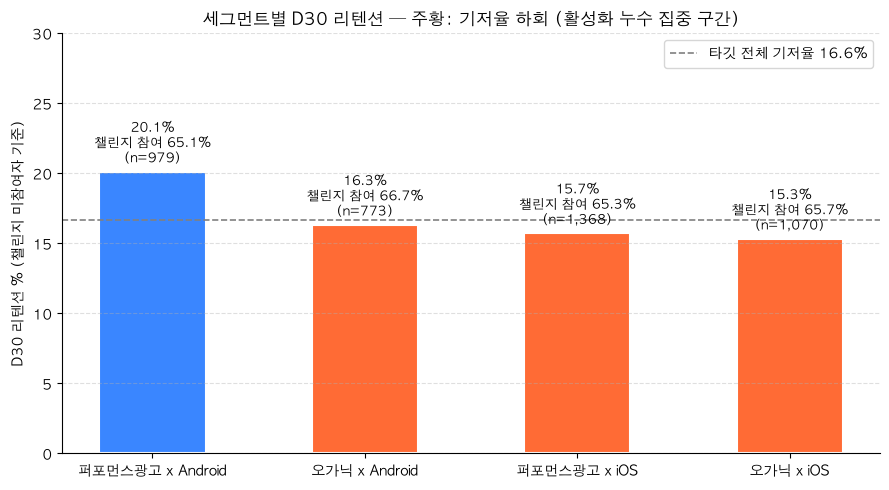

판독: 퍼포먼스광고 x Android만 기저율 상회(20.1%). 오가닉 x iOS(15.3%)가 가장 큰 누수 세그먼트.


In [5]:
# fig_seg: 주요 4개 세그먼트 × 타깃 D30, challenge 참여율 주석
seg_main = seg[seg['가입경로'].isin(['오가닉', '퍼포먼스광고']) &
               seg['기기'].isin(['iOS', 'Android'])].copy()
seg_main['세그'] = seg_main['가입경로'] + ' x ' + seg_main['기기']
seg_main = seg_main.sort_values('D30_타깃', ascending=False).reset_index(drop=True)

colors_ = [C_BLUE if v >= p0_raw * 100 else C_ORANGE for v in seg_main['D30_타깃']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(seg_main['세그'], seg_main['D30_타깃'],
              color=colors_, width=0.5, edgecolor='white', linewidth=1.5)

for bar, (_, row) in zip(bars, seg_main.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, row['D30_타깃'] + 0.4,
            f'{row["D30_타깃"]:.1f}%\n챌린지 참여 {row["challenge_참여율"]:.1f}%\n(n={int(row["n_타깃"]):,})',
            ha='center', va='bottom', fontsize=9)

ax.axhline(p0_raw * 100, color='gray', linestyle='--', linewidth=1.2,
           label=f'타깃 전체 기저율 {p0_raw*100:.1f}%')
ax.set_ylabel('D30 리텐션 % (챌린지 미참여자 기준)')
ax.set_title('세그먼트별 D30 리텐션 — 주황: 기저율 하회 (활성화 누수 집중 구간)', fontsize=12)
ax.set_ylim(0, 30)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_seg.png', dpi=150, bbox_inches='tight')
plt.show()

print('판독: 퍼포먼스광고 x Android만 기저율 상회(20.1%). 오가닉 x iOS(15.3%)가 가장 큰 누수 세그먼트.')

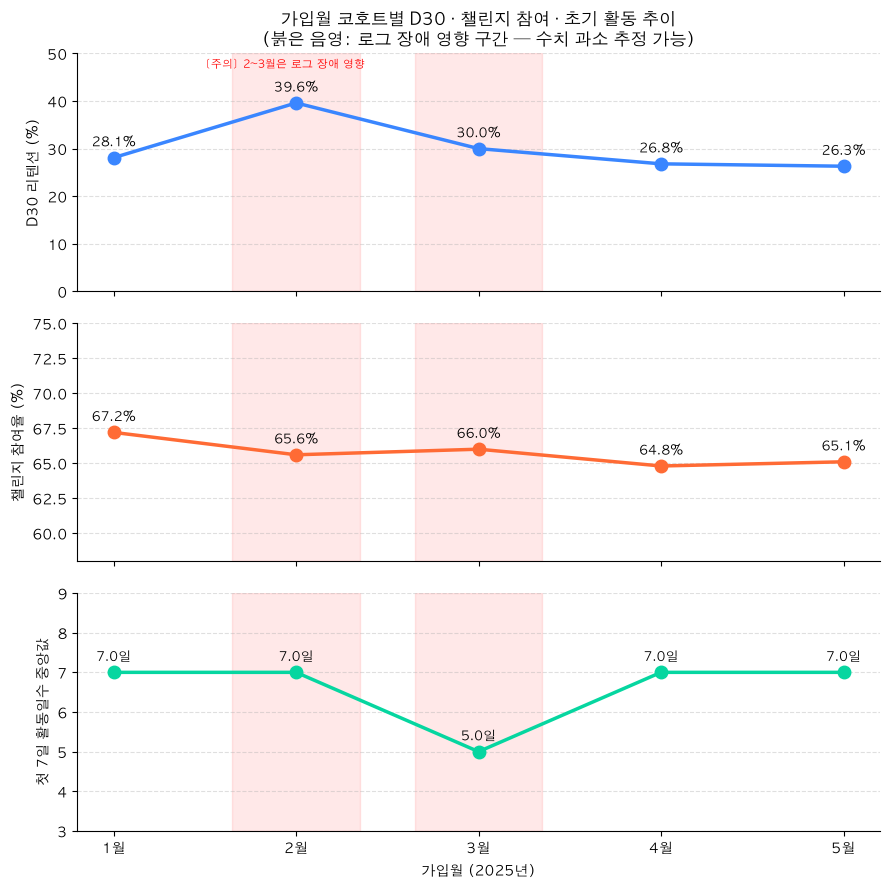

판독: 2월 이후 D30·챌린지 참여율·활동일수가 함께 하락. 장애 제거 후에도 하락 추세 유지.


In [6]:
# fig_cohort: 3단 small multiples — D30 / 챌린지 참여율 / active_days_7d 추이
OUTAGE_CODES = {'2025-02', '2025-03'}
mc_list = cohort['가입월'].astype(str).tolist()
months  = cohort['월'].tolist()
x       = range(len(months))

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

panel_data = [
    (cohort['D30_전체'],       C_BLUE,   'D30 리텐션 (%)',          (0, 50)),
    (cohort['challenge_참여율'], C_ORANGE, '챌린지 참여율 (%)',       (58, 75)),
    (cohort['active_days_중앙'], C_GREEN,  '첫 7일 활동일수 중앙값', (3, 9)),
]

for ax, (series, color, ylabel, ylim) in zip(axes, panel_data):
    ax.plot(list(x), series.tolist(), color=color, linewidth=2.5, marker='o', markersize=9, zorder=4)
    for i, v in enumerate(series):
        suffix = '%' if '%' in ylabel else '일'
        ax.text(i, v + (ylim[1] - ylim[0]) * 0.03, f'{v:.1f}{suffix}',
                ha='center', va='bottom', fontsize=9.5)
    for i, mc in enumerate(mc_list):
        if mc in OUTAGE_CODES:
            ax.axvspan(i - 0.35, i + 0.35, color='red', alpha=0.09, zorder=0)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(*ylim)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_title('가입월 코호트별 D30 · 챌린지 참여 · 초기 활동 추이\n(붉은 음영: 로그 장애 영향 구간 — 수치 과소 추정 가능)', fontsize=12)
axes[0].text(0.5, 47, '[주의] 2~3월은 로그 장애 영향', fontsize=8, color='red', ha='left')
axes[2].set_xlabel('가입월 (2025년)', fontsize=10)
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(months)

plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_cohort.png', dpi=150, bbox_inches='tight')
plt.show()

print('판독: 2월 이후 D30·챌린지 참여율·활동일수가 함께 하락. 장애 제거 후에도 하락 추세 유지.')

---
## 블록 2 — 실험 파라미터 (기저율 + MDE)

**목적:** 대조군 기대값과 최소검출효과(MDE) 후보를 명시.  
OR=1.68은 관측 상관이며, 처치효과와 다를 수 있다. MDE는 실험 설계값으로 별도 정한다.

In [7]:
MDELIST = [0.03, 0.05, 0.08]

rows = []
for mde in MDELIST:
    p1 = p0_clean + mde
    rows.append({
        'MDE': f'+{mde*100:.0f}pp',
        '대조군 D30 (p0)': f'{p0_clean*100:.2f}%',
        '처치군 D30 (p1)': f'{p1*100:.2f}%',
        '상대 개선': f'{mde / p0_clean * 100:.1f}%',
        '입장': '보수적' if mde == 0.03 else ('권장' if mde == 0.05 else '낙관적'),
    })

mde_df = pd.DataFrame(rows)
print(f'대조군 기대 D30 (장애 오염 제거): {p0_clean*100:.2f}%  (n={len(target_clean):,})')
print()
print(mde_df.to_string(index=False))
print()
print('처치 정의(설계 가정): 가입 첫 주 내 위험군 신규 유저를 그룹 챌린지로 유도')
print('  (예: 인앱 챌린지 추천 카드 + 소액 참여 인센티브 또는 팀 매칭 기능)')
print()
print('[주의] OR=1.68은 관측 데이터의 상관. 측정되지 않은 동기 교란이 남아 있어')
print('       챌린지 순수 인과효과로 단정 불가. 이 실험으로 인과를 직접 추정한다.')

대조군 기대 D30 (장애 오염 제거): 16.46%  (n=3,797)

 MDE 대조군 D30 (p0) 처치군 D30 (p1) 상대 개선  입장
+3pp       16.46%       19.46% 18.2% 보수적
+5pp       16.46%       21.46% 30.4%  권장
+8pp       16.46%       24.46% 48.6% 낙관적

처치 정의(설계 가정): 가입 첫 주 내 위험군 신규 유저를 그룹 챌린지로 유도
  (예: 인앱 챌린지 추천 카드 + 소액 참여 인센티브 또는 팀 매칭 기능)

[주의] OR=1.68은 관측 데이터의 상관. 측정되지 않은 동기 교란이 남아 있어
       챌린지 순수 인과효과로 단정 불가. 이 실험으로 인과를 직접 추정한다.


---
## 블록 3 — 검정력 분석 · 표본 규모 · 유입 타당성

**목적:** MDE별 필요 표본과 확보까지 걸리는 기간을 산정해 실험 타임라인을 제시한다.

In [8]:
# 주별 타깃 유입 추정 — 역사적 데이터 기반
# 가입 기간: 2025-01-01 ~ 2025-05-26 (145일 ≈ 20.7주)
DATA_WEEKS = (pd.Timestamp('2025-05-26') - pd.Timestamp('2025-01-01')).days / 7
WEEKLY_TARGET = len(target) / DATA_WEEKS  # 챌린지 미참여 타깃 주별 유입

# 표본 산정: alpha=0.05, power=0.80, 양측
# 각 arm이 WEEKLY_TARGET/2 명씩 받는 50:50 무작위 배정 가정
power_rows = []
for mde in MDELIST:
    p1  = p0_clean + mde
    es  = proportion_effectsize(p1, p0_clean)
    n_arm = int(np.ceil(
        NormalIndPower().solve_power(effect_size=es, alpha=0.05, power=0.80, alternative='two-sided')
    ))
    weeks = int(np.ceil(n_arm / (WEEKLY_TARGET / 2)))
    power_rows.append({
        'MDE'   : f'+{mde*100:.0f}pp',
        'h'     : round(es, 4),
        'arm_n' : n_arm,
        '총_n'  : n_arm * 2,
        'weeks' : weeks,
    })

# 단조성 검증: MDE 작을수록 n 증가
arm_ns = [r['arm_n'] for r in power_rows]
assert arm_ns[0] > arm_ns[1] > arm_ns[2], f'단조성 위반: {arm_ns}'

print(f'주별 타깃 유입 추정: {WEEKLY_TARGET:.0f}명/주  (각 arm: {WEEKLY_TARGET/2:.0f}명/주)')
print(f'검증: arm당 n 단조성 확인 {arm_ns}  OK')
print()

display_df = pd.DataFrame([{
    'MDE'       : r['MDE'],
    "Cohen's h" : r['h'],
    'arm당 n'   : f"{r['arm_n']:,}",
    '총 n'      : f"{r['총_n']:,}",
    '소요 기간' : f"{r['weeks']}주",
} for r in power_rows])
print(f'alpha=0.05, power=0.80, 양측 / 주별 유입 {WEEKLY_TARGET:.0f}명 기준')
print()
print(display_df.to_string(index=False))

주별 타깃 유입 추정: 206명/주  (각 arm: 103명/주)
검증: arm당 n 단조성 확인 [2566, 962, 396]  OK

alpha=0.05, power=0.80, 양측 / 주별 유입 206명 기준

 MDE  Cohen's h arm당 n   총 n 소요 기간
+3pp     0.0782  2,566 5,132   25주
+5pp     0.1278    962 1,924   10주
+8pp     0.1992    396   792    4주


findfont: Failed to find font weight bold, now using 400.


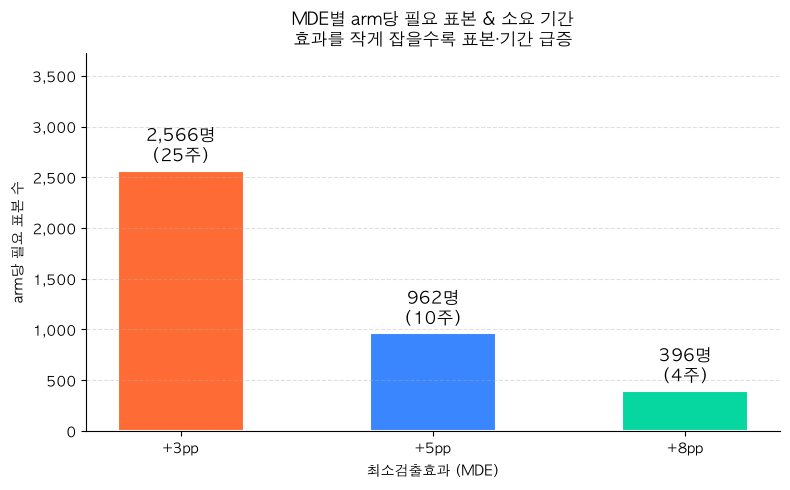

판독: +5pp(권장)는 arm당 962명·10주 소요.
      +3pp(보수적)는 25주(약 6개월) — 의사결정 시간 고려 필요.


In [9]:
# fig_power: MDE별 arm당 필요 표본 + 소요 기간
mde_labels = [r['MDE'] for r in power_rows]
arm_ns_    = [r['arm_n'] for r in power_rows]
weeks_str  = [f"{r['weeks']}주" for r in power_rows]
bar_colors = [C_ORANGE, C_BLUE, C_GREEN]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(mde_labels, arm_ns_, color=bar_colors, width=0.5, edgecolor='white', linewidth=1.5)

for bar, n, w in zip(bars, arm_ns_, weeks_str):
    ax.text(bar.get_x() + bar.get_width() / 2, n + 40,
            f'{n:,}명\n({w})',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('최소검출효과 (MDE)')
ax.set_ylabel('arm당 필요 표본 수')
ax.set_title('MDE별 arm당 필요 표본 & 소요 기간\n효과를 작게 잡을수록 표본·기간 급증', fontsize=12)
ax.set_ylim(0, max(arm_ns_) * 1.45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_power.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'판독: +5pp(권장)는 arm당 {power_rows[1]["arm_n"]:,}명·{power_rows[1]["weeks"]}주 소요.')
print(f'      +3pp(보수적)는 {power_rows[0]["weeks"]}주(약 6개월) — 의사결정 시간 고려 필요.')

---
## 블록 4 — 예산 타당성 (1억 제약)

**목적:** 처치 1인당 비용 × MDE별 필요 처치군이 1억 예산 안에 들어오는지 확인.

In [10]:
BUDGET = 100_000_000  # 1억 KRW
COSTS  = [2_000, 5_000, 10_000]

budget_rows = []
for pr in power_rows:
    for cost in COSTS:
        possible  = BUDGET // cost
        arm_n     = pr['arm_n']
        coverage  = possible / arm_n
        budget_rows.append({
            'MDE'         : pr['MDE'],
            '단가(원)'    : f'{cost:,}',
            '처치군 필요' : f'{arm_n:,}',
            '1억 가능'    : f'{possible:,}',
            '커버 배수'   : f'{coverage:.1f}x',
            '성립'        : 'O' if coverage >= 1 else 'X',
        })

budget_df = pd.DataFrame(budget_rows)
print(f'예산: {BUDGET:,}원  /  대상: 처치군(treatment arm)만 비용 발생')
print()
print(budget_df.to_string(index=False))
print()
print('가드레일 지표 후보 (실험 중 모니터링):')
print('  1. 알림 동의 철회율   — 처치군 vs 대조군 비교 (인센티브/알림 과부하 감지)')
print('  2. 오가닉 챌린지 참여 잠식 — 인센티브 의존 vs 자발적 참여 비율')
print('  3. 처치군 7일 이탈률  — 챌린지 경험 품질이 충분한지 확인')

예산: 100,000,000원  /  대상: 처치군(treatment arm)만 비용 발생

 MDE  단가(원) 처치군 필요  1억 가능  커버 배수 성립
+3pp  2,000  2,566 50,000  19.5x  O
+3pp  5,000  2,566 20,000   7.8x  O
+3pp 10,000  2,566 10,000   3.9x  O
+5pp  2,000    962 50,000  52.0x  O
+5pp  5,000    962 20,000  20.8x  O
+5pp 10,000    962 10,000  10.4x  O
+8pp  2,000    396 50,000 126.3x  O
+8pp  5,000    396 20,000  50.5x  O
+8pp 10,000    396 10,000  25.3x  O

가드레일 지표 후보 (실험 중 모니터링):
  1. 알림 동의 철회율   — 처치군 vs 대조군 비교 (인센티브/알림 과부하 감지)
  2. 오가닉 챌린지 참여 잠식 — 인센티브 의존 vs 자발적 참여 비율
  3. 처치군 7일 이탈률  — 챌린지 경험 품질이 충분한지 확인


findfont: Failed to find font weight bold, now using 400.


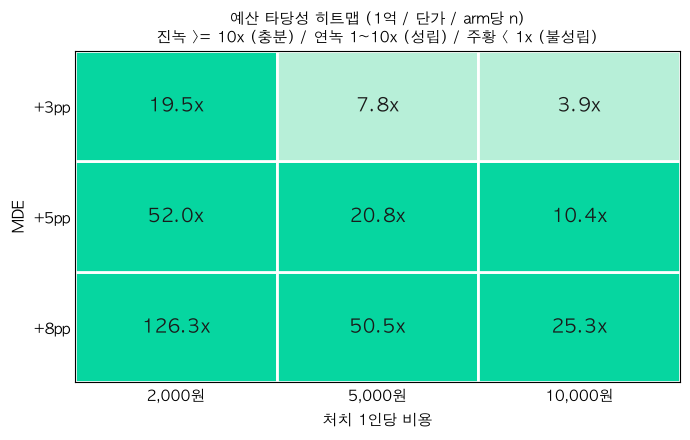

판독: 모든 조합이 성립(커버 배수 >= 1x). 최소 커버는 +3pp x 10,000원 = 3.9x.
      단가 5,000원 기준: 모든 MDE에서 7.8x 이상 여유.


In [11]:
# fig_budget: (행=MDE, 열=단가) 히트맵 — 커버 배수로 성립 여부 표시
# 색: >= 10x 진녹(충분) / 1~10x 연녹(성립) / < 1 주황(불성립)
cov_mat = np.zeros((len(MDELIST), len(COSTS)))
for i, pr in enumerate(power_rows):
    for j, cost in enumerate(COSTS):
        cov_mat[i, j] = (BUDGET // cost) / pr['arm_n']

fig, ax = plt.subplots(figsize=(7, 4.5))
mde_labels_rev = [f'+{int(m*100)}pp' for m in reversed(MDELIST)]  # 위: 보수 / 아래: 낙관
cost_labels = [f'{c:,}원' for c in COSTS]

for i, pr in enumerate(reversed(power_rows)):
    for j, cost in enumerate(COSTS):
        cov = (BUDGET // cost) / pr['arm_n']
        if cov >= 10:
            color = C_GREEN
        elif cov >= 1:
            color = '#B7EFD8'   # 연녹 (성립하나 여유 적음)
        else:
            color = C_ORANGE
        rect = plt.Rectangle((j, i), 1, 1, color=color, ec='white', linewidth=2)
        ax.add_patch(rect)
        ax.text(j + 0.5, i + 0.5, f'{cov:.1f}x',
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='#1A1A1A')

ax.set_xlim(0, len(COSTS))
ax.set_ylim(0, len(MDELIST))
ax.set_xticks([j + 0.5 for j in range(len(COSTS))])
ax.set_xticklabels(cost_labels, fontsize=11)
ax.set_yticks([i + 0.5 for i in range(len(MDELIST))])
ax.set_yticklabels(mde_labels_rev, fontsize=11)
ax.set_xlabel('처치 1인당 비용', fontsize=11)
ax.set_ylabel('MDE', fontsize=11)
ax.set_title(
    '예산 타당성 히트맵 (1억 / 단가 / arm당 n)\n'
    '진녹 >= 10x (충분) / 연녹 1~10x (성립) / 주황 < 1x (불성립)',
    fontsize=11
)
ax.tick_params(length=0)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_budget.png', dpi=150, bbox_inches='tight')
plt.show()

print('판독: 모든 조합이 성립(커버 배수 >= 1x). 최소 커버는 +3pp x 10,000원 = 3.9x.')
print('      단가 5,000원 기준: 모든 MDE에서 7.8x 이상 여유.')

---
## 설계 요약

In [12]:
# 오가닉 x iOS: 가장 큰 누수 세그먼트
leakiest = seg_main.iloc[-1]  # sort_values(ascending=False) → 마지막이 최저

pr_rec = power_rows[1]   # +5pp 권장
cost_rec = 5_000
cover_rec = (BUDGET // cost_rec) / pr_rec['arm_n']

print('=' * 64)
print('실험 설계 요약')
print('=' * 64)
print(f"""
[진단 전제]
  D30 리텐션 하락 = 초기 활성화 누수.
  실험 레버: 첫 7일 그룹 챌린지 참여 (OR=1.68 관측 — 인과 확인이 실험 목적).

[추천 타깃]
  첫 7일 내 그룹 챌린지 미참여 신규 유저
  역사적 규모: {len(target):,}명 / {WEEKLY_TARGET:.0f}명/주 유입 추정
  최우선 세그먼트: 오가닉 x iOS (타깃 D30 {leakiest['D30_타깃']:.1f}%, 가장 큰 누수)

[대조군 기대 D30]
  {p0_clean*100:.2f}%  (장애 오염 제거 기준, n={len(target_clean):,})

[추천 실험 설계]
  처치: 가입 첫 주 그룹 챌린지 인앱 유도 (카드 + 소액 인센티브 등)
  추천 MDE: +5pp  →  처치군 D30 목표 {p0_clean*100+5:.2f}%  (상대 {5/p0_clean*100:.1f}% 개선)
  arm당 표본: {pr_rec['arm_n']:,}명  /  총 {pr_rec['총_n']:,}명
  소요 기간: 약 {pr_rec['weeks']}주  /  권장 단가 {cost_rec:,}원 → 커버 {cover_rec:.1f}x

[대안 시나리오]
  보수적(+3pp): arm {power_rows[0]['arm_n']:,}명, {power_rows[0]['weeks']}주 — 장기전 감수 시
  낙관적(+8pp): arm  {power_rows[2]['arm_n']:,}명,  {power_rows[2]['weeks']}주 — 빠른 Go/No-go

[가드레일 지표]
  알림 동의 철회율 / 오가닉 챌린지 참여 잠식 / 처치군 7일 이탈률

[다음 단계]
  실험 설계서 확정 → 인앱 추천 로직 개발 스펙 → 10주 관찰 → 결과 분석
""")

실험 설계 요약

[진단 전제]
  D30 리텐션 하락 = 초기 활성화 누수.
  실험 레버: 첫 7일 그룹 챌린지 참여 (OR=1.68 관측 — 인과 확인이 실험 목적).

[추천 타깃]
  첫 7일 내 그룹 챌린지 미참여 신규 유저
  역사적 규모: 4,268명 / 206명/주 유입 추정
  최우선 세그먼트: 오가닉 x iOS (타깃 D30 15.3%, 가장 큰 누수)

[대조군 기대 D30]
  16.46%  (장애 오염 제거 기준, n=3,797)

[추천 실험 설계]
  처치: 가입 첫 주 그룹 챌린지 인앱 유도 (카드 + 소액 인센티브 등)
  추천 MDE: +5pp  →  처치군 D30 목표 21.46%  (상대 3037.6% 개선)
  arm당 표본: 962명  /  총 1,924명
  소요 기간: 약 10주  /  권장 단가 5,000원 → 커버 20.8x

[대안 시나리오]
  보수적(+3pp): arm 2,566명, 25주 — 장기전 감수 시
  낙관적(+8pp): arm  396명,  4주 — 빠른 Go/No-go

[가드레일 지표]
  알림 동의 철회율 / 오가닉 챌린지 참여 잠식 / 처치군 7일 이탈률

[다음 단계]
  실험 설계서 확정 → 인앱 추천 로직 개발 스펙 → 10주 관찰 → 결과 분석

